## Uncertanity quantification for angle-stack AVA inversion with guided DDPM

**Overview:** This notebook implements and benchmarks two uncertainty quantification (UQ) frameworks for elastic parameter inversion from the synthetic Otway angle-stack seismic data:

1. **Analytical Bayesian inversion** (Buland & Omre, 2003): closed-form Gaussian posterior computed trace-by-trace using the linearized Aki-Richards forward operator. Serves as the exact posterior reference (Eqs. 1.21–1.25, report Sec. 1.3.6).

2. **Diffusion Posterior Sampling (DPS)**: generates an ensemble of 100 independent posterior realizations using a pretrained 3-channel DDPM prior guided by data-consistency gradient corrections at each reverse diffusion step (Eq. 1.18, report Sec. 1.3.4).

### 1. Imports and device setup

Core dependencies:
- `pylops`: matrix-free linear operators for the AVA forward model **G** (Eq. 1.7)
- `diffusers` (HuggingFace): `UNet2DModel`, `DDPMScheduler`, `DDIMScheduler` for the DDPM prior
- `diffavoinv`: project package containing `dps_avo_inversion` (DPS guidance loop), `ddim_inversion_and_sampling`, and normalization utilities
- Device is auto-selected (GPU if available); the DDPM inference loop is GPU-accelerated

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import pylops
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from pylops.basicoperators import Identity, Laplacian
from diffusers import UNet2DModel, DDPMPipeline, DDPMScheduler, DDIMScheduler
from scipy.ndimage import gaussian_filter

from diffavoinv.dps_avo_inversion import *
from diffavoinv.ddim_inversion_and_sampling import *
from diffavoinv.utils import *

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/dixita/anaconda3/envs/diffseisavo/lib/python3.9/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


### 2. Evaluation metric helpers

- `snr_db`: signal-to-noise ratio in dB, defined as 20 log10(||gt|| / ||gt − pred||).
- `ssim_val`: structural similarity index (SSIM), measuring perceptual/structural fidelity.
- `power_iteration_norm`: estimates the spectral norm of a matrix via power iteration; useful for diagnosing the conditioning of the forward operator **G**.

In [2]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

def snr_db(gt, pred, eps=1e-12):
    num = np.linalg.norm(gt.ravel(), 2)
    den = np.linalg.norm((gt - pred).ravel(), 2)
    return 20.0 * np.log10((num + eps) / (den + eps))

def ssim_val(gt, pred):
    dr = float(gt.max() - gt.min())
    if dr == 0:
        return 1.0
    return ssim(gt, pred, data_range=dr)


def power_iteration_norm(A, niter=30):
    x = np.random.randn(A.shape[1])
    x /= np.linalg.norm(x)

    for _ in range(niter):
        x = A.T @ (A @ x)
        x /= np.linalg.norm(x)

    Ax = A @ x
    return np.linalg.norm(Ax)

### 3. Depth-to-time conversion utility

The Otway model is in the depth domain. Since seismic AVA inversion operates in two-way traveltime (TWT), all elastic models must be converted before building the forward operator. The function preserves exactly nz=128 samples (nt = nz) so the grid dimensions remain compatible with the trained DDPM (which expects 128×256 patches).

In [3]:
import numpy as np

def depth2time_same_pixels(vp, vs, rho, dz, vp_floor=500.0, use_smoothed_vp_for_mapping=False):
    """
    Convert depth-sampled elastic model to time-sampled model with SAME number of samples (nt = nz).
    dt is chosen automatically from global tmax (max bottom TWT across x).

    Inputs:
      vp, vs, rho: (nz, nx) or (nz,)
      dz: depth sampling in meters
      vp_floor: minimum vp to avoid division issues
      use_smoothed_vp_for_mapping: if True, use a simple vertical smoothing for mapping (optional)

    Returns:
      dt: scalar time sampling (seconds)
      t_grid: (nz,) global TWT grid
      vp_t, vs_t, rho_t: (nz, nx) time-resampled models (or (nz,) if input was 1D)
      t_twt: (nz, nx) per-trace TWT mapping from depth samples (useful for QC)
    """
    vp = np.asarray(vp, dtype=np.float64)
    vs = np.asarray(vs, dtype=np.float64)
    rho = np.asarray(rho, dtype=np.float64)

    is_1d = (vp.ndim == 1)
    if is_1d:
        vp = vp[:, None]; vs = vs[:, None]; rho = rho[:, None]

    nz, nx = vp.shape

    # --- optional: mild vertical smoothing for the time mapping only ---
    if use_smoothed_vp_for_mapping:
        # simple 1D moving average along z (no scipy)
        w = 9  # odd window
        ker = np.ones(w) / w
        vp_map = np.empty_like(vp)
        for ix in range(nx):
            vp_map[:, ix] = np.convolve(vp[:, ix], ker, mode="same")
    else:
        vp_map = vp

    vp_safe = np.maximum(vp_map, vp_floor)

    # TWT mapping for each trace: t(z,x) = 2 * cumsum(dz / vp)
    t_twt = 2.0 * np.cumsum(dz / vp_safe, axis=0)  # (nz, nx)

    # choose ONE global tmax so every trace shares the same time grid and dt
    tmax = float(np.nanmax(t_twt[-1, :]))  # bottom time, max over x
    dt = tmax / (nz - 1)

    t_grid = np.linspace(0.0, tmax, nz)  # (nz,)

    vp_t  = np.empty((nz, nx), dtype=np.float32)
    vs_t  = np.empty((nz, nx), dtype=np.float32)
    rho_t = np.empty((nz, nx), dtype=np.float32)

    for ix in range(nx):
        tt = t_twt[:, ix]
        tt = np.maximum.accumulate(tt)  # enforce monotonicity

        # interpolate depth-sampled properties onto the common time grid
        vp_t[:, ix]  = np.interp(t_grid, tt, vp[:, ix]).astype(np.float32)
        vs_t[:, ix]  = np.interp(t_grid, tt, vs[:, ix]).astype(np.float32)
        rho_t[:, ix] = np.interp(t_grid, tt, rho[:, ix]).astype(np.float32)

    if is_1d:
        return dt, t_grid, vp_t[:, 0], vs_t[:, 0], rho_t[:, 0], t_twt[:, 0]

    return dt, t_grid, vp_t, vs_t, rho_t, t_twt

### 4. Load Otway elastic model and convert to time domain

Loads the 2D Otway synthetic model (nz=128, nx=256) from the pre-saved `.npz` file. The Otway model is deliberately an **out-of-distribution** test case: the DDPM was trained on SEAM Arid, Overthrust, and Marmousi2 datasets (Sec. 1.3.5), not on Otway.

The bottom two rows of all three parameters are padded with constant values (Vp=3400 m/s, Vs=1800 m/s, ρ=2450 kg/m³) to suppress edge-effect artefacts at the model boundary during reflectivity computation.

`depth2time_same_pixels` converts the depth-domain models to TWT, as defined in above cell.

In [4]:
file = np.load('../data/C_Otway2D/otway_128_256.npz')
# print(sample.shape, sample.dtype)

vp = file['m'][0].astype(np.float64)
vs = file['m'][1].astype(np.float64)
rho = file['m'][2].astype(np.float64) # keeping in kg/m3

vp[-2:,:] = 3400
vs[-2:,:] = 1800.0
rho[-2:,:] = 2450

vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]

x, z = file['x'], file['z']
nz,nx = vp.shape
dz, dx = z[1]-z[0], x[1]-x[0]

# Covert Otway in time domain:
dt, t, vp_t, vs_t, rho_t, tmap = depth2time_same_pixels(vp, vs, rho, dz)

print("nt (time samples) =", vp_t.shape[0], "should equal nz")
print("auto dt =", dt, "seconds")

extent = [x[0], x[-1], t[-1], t[0]]

nt (time samples) = 128 should equal nz
auto dt = 0.013071403046346311 seconds


---
## Part I: Pretrained DDPM prior — load and validate

### 5. Load pretrained 3-channel DDPM and scheduler

Loads the pretrained DDPM from a saved checkpoint. The model is a 2D U-Net trained for 500 epochs on 5,000 high-resolution elastic models (128×256) with T=1000 diffusion timesteps using epsilon-prediction, as described in Sec. 1.3.5.

In [ ]:

load_dir = Path('../dpsAVOinversion-dev/data/checkpoints/3ch-ddpm-20260430-104648') # updated checkpoint with global normalization--with 800 epoch
# UNet
model = UNet2DModel.from_pretrained(load_dir).to(device)

# Scheduler (note the subfolder)
scheduler = DDPMScheduler.from_pretrained(load_dir / "scheduler")

assert scheduler.config.prediction_type == "epsilon"          # or whatever you trained with
assert scheduler.config.num_train_timesteps == 1000           # match training

/home/dixita/anaconda3/envs/diffseisavo/lib/python3.9/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


### 6. Unconditional prior sampling — qualitative prior validation

Before running guided inversion, the learned prior p(m) is qualitatively validated by generating 5 independent unconditional samples — i.e., pure reverse diffusion from Gaussian noise with no data conditioning (μ=0 in Eq. 1.18 of the report).

In [ ]:
# Number of time steps for sampling:
num_inference_steps=100
scheduler.set_timesteps(num_inference_steps)


# Unconditional generation
n_gen=5
unconditionals_samples = []
for gen in range(n_gen):
    # Unconditional DDIM sampling
    generated = sample_unconditional(model, scheduler, num_inference_steps,  device=device, shape=(1,3,128,256))
    unconditional_sample_np = generated[0,0].detach().cpu().numpy()
    unconditionals_samples.append(generated)

### 7. Stack unconditional samples into a NumPy array

Converts the list of generated GPU tensors to a single NumPy array of shape (n_gen, 3, nz, nx). Samples remain in normalized [−1, 1] space throughout.

In [7]:
samples_np = [s[0].detach().cpu().numpy() for s in unconditionals_samples]
samples_un = np.array(samples_np)
samples_un.shape

(5, 3, 128, 256)

### 8. Visualize unconditional prior samples (Figure 1.1a equivalent)

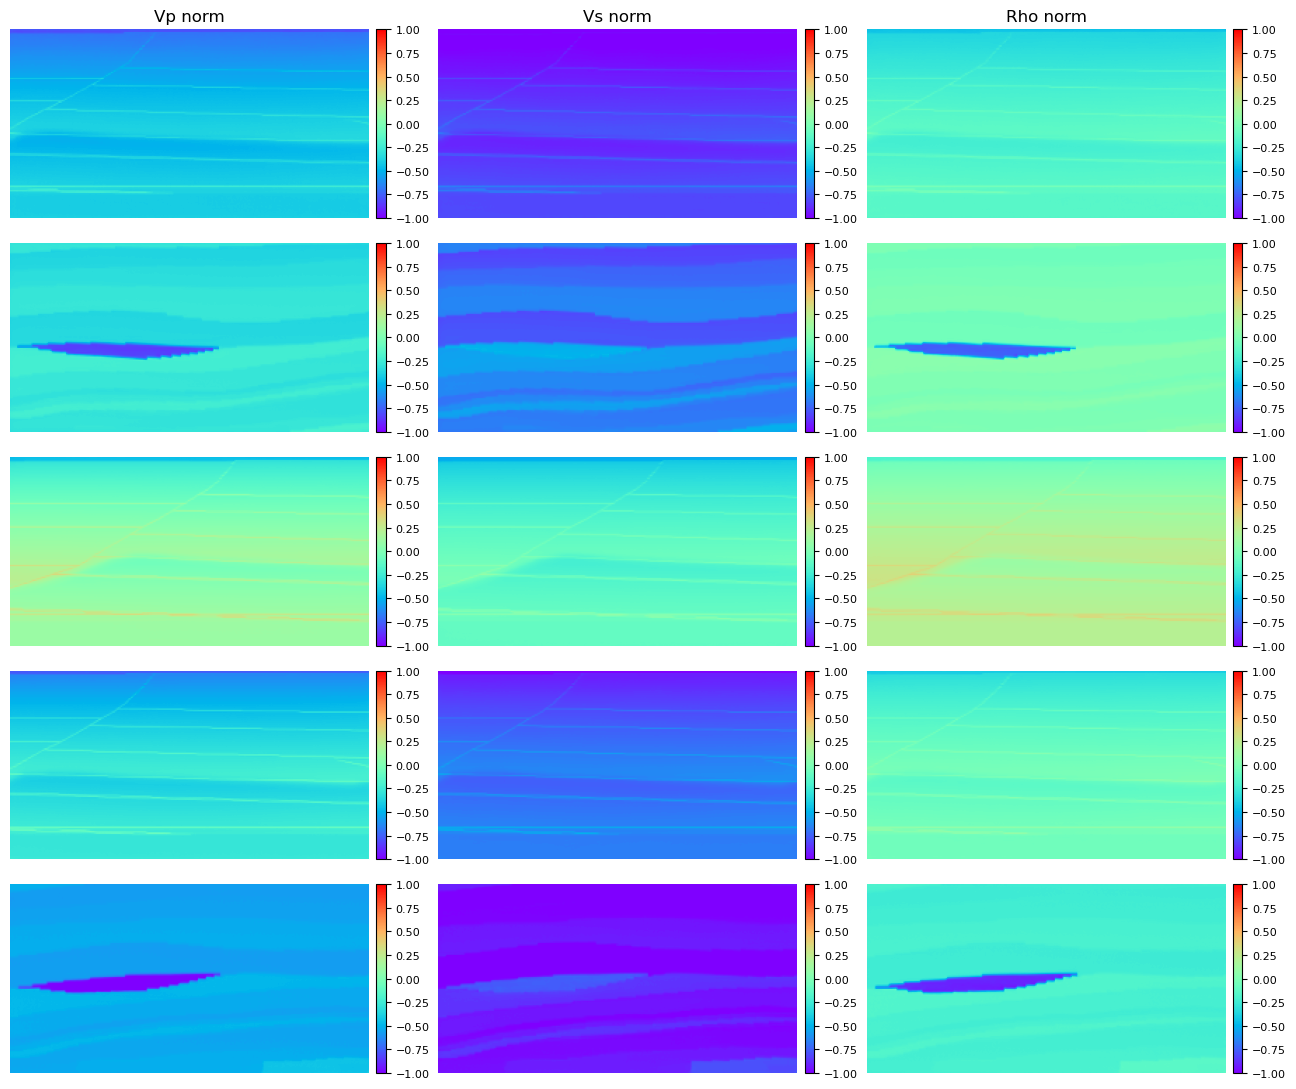

In [ ]:
# Visulization of uncondationally generated samples
import numpy as np
import matplotlib.pyplot as plt

# --- Visualization parameters ---
vmin, vmax = -1, 1
cmap = "rainbow"

# --- Convert tensors to numpy ---
# Each sample: (3, H, W)
samples_np = [s[0].detach().cpu().numpy() for s in unconditionals_samples]
n_samples = 5     #len(samples_np)

# --- Column titles ---
col_titles = ["Vp norm", "Vs norm", "Rho norm"]

# --- Create figure (wide panels) ---
fig, axes = plt.subplots(
    nrows=n_samples,
    ncols=3,
    figsize=(13, 2.2 * n_samples),  # <<< wider than tall


    squeeze=False
)

for i in range(n_samples):        # rows → samples
    for j in range(3):            # cols → channels
        ax = axes[i, j]

        im = ax.imshow(
            samples_np[i][j],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto"        
        )

        ax.axis("off")

        # Titles only on first row
        if i == 0:
            ax.set_title(col_titles[j], fontsize=12)

        # Colorbar for each subplot
        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.035,
            pad=0.02
        )
        cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


---
## Part II: Forward operator and synthetic seismic data generation

The following cells build the complete forward modelling chain required for inversion:
true elastic model (depth) → time-domain conversion → log parameterization → Aki-Richards operator **G** → angle-stack seismic data with 3% Gaussian noise.
This replicates the experimental setup of Section 1.4.1 of the report.

### 9. Reload Otway model and display true elastic parameter sections

nt (time samples) = 128 should equal nz
auto dt = 0.013071403046346311 seconds
vp min/max: 1475.833251953125 3709.880126953125
vs min/max: 626.111083984375 2136.875732421875
rho min/max: 1788.888916015625 3474.852294921875


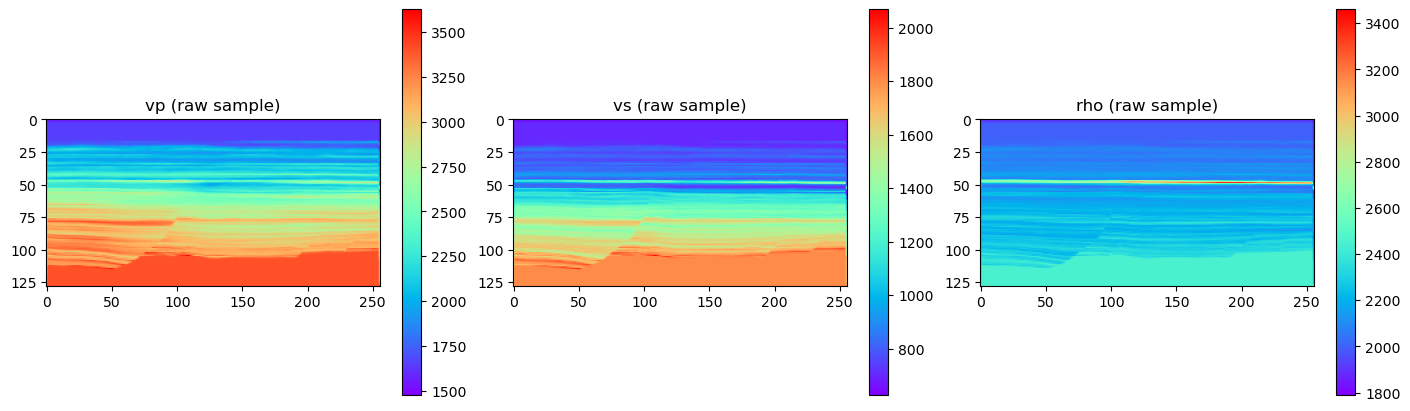

In [ ]:
# Load a sample from the dataset:
file = np.load('../dpsAVOinversion-dev/data/C_Otway2D/otway_128_256.npz')
# print(sample.shape, sample.dtype)

vp = file['m'][0].astype(np.float64)
vs = file['m'][1].astype(np.float64)
rho = file['m'][2].astype(np.float64)  #  (kg/m^3)

vp[-2:,:] = 3400
vs[-2:,:] = 1800.0
rho[-2:,:] = 2450

vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]

x, z = file['x'], file['z']
nz,nx = vp.shape
dz, dx = z[1]-z[0], x[1]-x[0]

dt, t, vp_t, vs_t, rho_t, tmap = depth2time_same_pixels(vp, vs, rho, dz)
print("nt (time samples) =", vp_t.shape[0], "should equal nz")
print("auto dt =", dt, "seconds")

extent = [x[0], x[-1], t[-1], t[0]]

# print("Loaded sample shape:", sample.shape, " -> nz,nx =", nz, nx)
print("vp min/max:", vp.min(), vp.max())
print("vs min/max:", vs.min(), vs.max())
print("rho min/max:", rho.min(), rho.max())

# 9a) show vp/vs/rho patches (input)
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp_t, cmap='rainbow');  axs[0].set_title("vp (raw sample)");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs_t, cmap='rainbow');  axs[1].set_title("vs (raw sample)");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho_t, cmap='rainbow'); axs[2].set_title("rho (raw sample)"); plt.colorbar(im, ax=axs[2])
plt.show()

### 10. Log parameterization, background model, wavelet, operator, and angle stacks

**Log-domain parameterization:** Following Eq. 1.8 of the report, the elastic model is represented as m = [ln Vp, ln Vs, ln ρ]^T. This choice linearizes the Aki-Richards reflectivity so that log-differences approximate relative contrasts (∆ln Vp ≈ ∆Vp / V̄p), making the forward problem **d = G m + n** linear in m.

**Smooth background model (mback):** Obtained by Gaussian filtering the true log-model with σ_z=8 samples vertically and σ_x=12 samples laterally. 

**Ricker wavelet:** Peak frequency f0=150 Hz is chosen to resolve the fine-layer structure of the Otway model

**PrestackLinearModelling (PPop):** The pylops matrix-free operator G ∈ R^(Nθ·nz × 3N) implements wavelet convolution followed by Aki-Richards weighting (linearization="akirich", Eqs. 1.3–1.5). `explicit=False` avoids forming the dense matrix, using adjoint-based operations instead (Eq. 1.16, G^H term).

**Synthetic noisy data:** Full prestack gathers dPP (nz × 27 angles × nx) are generated then corrupted with 3% Gaussian noise (noise_std=3e-2), consistent with the experimental setup in Sec. 1.4.1 of the report.

**Angle stacks:** The dense prestack is averaged into three angle stacks with bin edges [3°, 10°, 20°, 30°] — near (3°–10°), mid (10°–20°), far (20°–30°) — matching Figure 1.2 of the report. A compact 3-angle representative operator G at the bin-centre angles (6.5°, 15°, 25°) is then built for the inversion guidance.

m shape: (128, 3, 256)
wav length: 11
Operator shape: (884736, 98304) (data_size, model_size)
mvec: (98304,) dvec: (884736,)
dPP: (128, 27, 256) dPPn: (128, 27, 256)
ithetas: [0, 7, 17, 26] counts: [ 7 10  9]
stacks shape: (128, 3, 256)


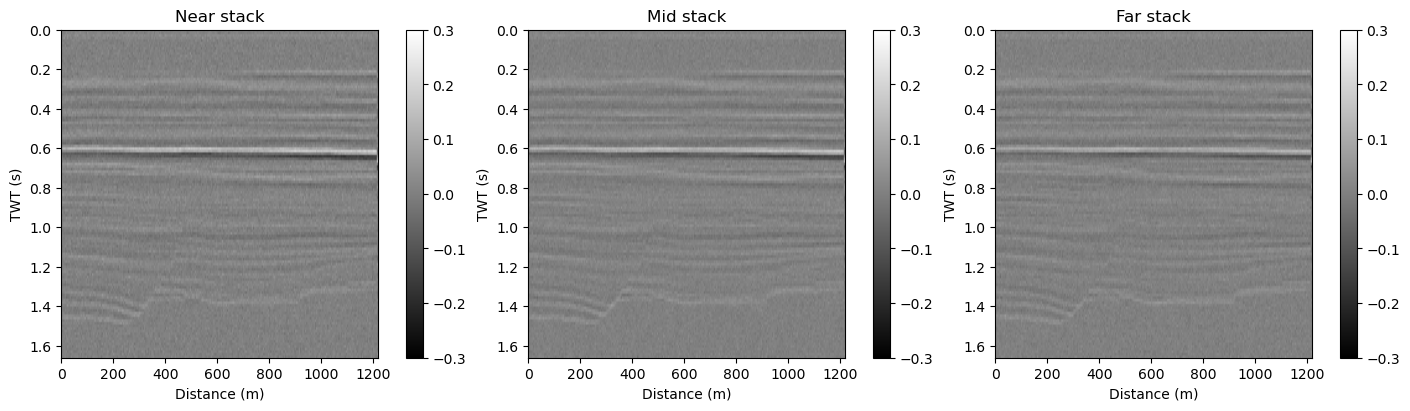

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import pylops
from pylops.utils.wavelets import ricker

# -------------------------------------
# Build true model 'm' in log domain:
# -------------------------------------
m = np.log(np.stack((vp_t, vs_t, rho_t), axis=1))  # (nz, 3, nx)
print("m shape:", m.shape)

# -------------------------------------
# Smooth 'm' for initial model mback
# -------------------------------------
sigma_z = 8.0     # vertical smoothing (samples)
sigma_x = 12.0    # lateral smoothing  (samples)

mback = np.empty_like(m)
for ip in range(3):
    mback[:, ip, :] = gaussian_filter(
        m[:, ip, :], sigma=(sigma_z, sigma_x), mode="nearest"
    )

# -------------------------
# Wavelet and angles
# -------------------------
dt0 = dt  # s
f0 = 150.0
ntwav = 11

tw = (np.arange(ntwav) - ntwav // 2) * dt0
wav = ricker(tw, f0=f0)[0][:ntwav]
print("wav length:", len(wav))

# Use DEGREES for angle definition (consistent with bin_edges_deg)
ntheta = 27
theta_min_deg, theta_max_deg = 3.0, 30.0   # IMPORTANT: must cover your bins
theta_deg = np.linspace(theta_min_deg, theta_max_deg, ntheta)

# -------------------------
# Build linear operator
# -------------------------
PPop = pylops.avo.prestack.PrestackLinearModelling(
    wav,
    theta_deg,
    nt0=nz,
    spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)
print("Operator shape:", PPop.shape, "(data_size, model_size)")

# -------------------------
# Forward model data dPP(z, theta, x)
# -------------------------
assert m.shape == (nz, 3, nx), m.shape

mvec = m.ravel(order="C")
dvec = PPop * mvec
dPP = dvec.reshape(nz, ntheta, nx, order="C")

# Add noise (in gather domain)
noise_std = 3e-2
rng = np.random.default_rng(0)
dPPn = dPP + rng.normal(0.0, noise_std, size=dPP.shape)

print("mvec:", mvec.shape, "dvec:", dvec.shape)
print("dPP:", dPP.shape, "dPPn:", dPPn.shape)

# -------------------------
# Angle stacks (near/mid/far)
# -------------------------
bin_edges_deg = [int(theta_min_deg), 10, 20, int(theta_max_deg)]  # must lie within [theta_min_deg, theta_max_deg]
ithetas = [np.searchsorted(theta_deg, e, side="left") for e in bin_edges_deg]

# check bins are non-empty
counts = np.diff(ithetas)
print("ithetas:", ithetas, "counts:", counts)
if np.any(counts == 0):
    raise ValueError(f"Empty angle bin detected. ithetas={ithetas}, theta_deg range={theta_deg[0]}–{theta_deg[-1]}")

# Stack the NOISY gathers (this is what you'd have in practice)
dPPn_stacks = np.stack(
    [dPPn[:, ithetas[i]:ithetas[i+1], :].mean(axis=1) for i in range(len(ithetas) - 1)],
    axis=1
)  # (nz, nbins, nx)

print("stacks shape:", dPPn_stacks.shape)  # (nz, 3, nx)

# -------------------------
# Plot near/mid/far stacks
# -------------------------
titles = ["Near stack", "Mid stack", "Far stack"]
clip = 0.3

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for i in range(3):
    im = axs[i].imshow(
        dPPn_stacks[:, i, :],
        cmap="gray",
        aspect="auto",
        origin="upper",
        vmin=-clip, vmax=clip,
        extent=extent
    )
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Distance (m)")
    axs[i].set_ylabel("TWT (s)")
    plt.colorbar(im, ax=axs[i])

plt.show()

thetas3_deg = np.array([(bin_edges_deg[0]+bin_edges_deg[1])/2, 
                        (bin_edges_deg[1]+bin_edges_deg[2])/2, 
                        (bin_edges_deg[2]+bin_edges_deg[3])/2]
                        , dtype=float)
# theta3 = np.deg2rad(thetas3_deg)

G =  pylops.avo.prestack.PrestackLinearModelling(
    wav, thetas3_deg, nt0=128, spatdims=(nx,),
    linearization="akirich",
    explicit=False
)

---
## Part III: Uncertainty Quantification — Analytical Bayesian Inversion

Implements the closed-form Gaussian posterior from Buland & Omre (2003), following Eqs. 1.21–1.25 of the report.

### 11. Trace-wise analytical Bayesian inversion

Implements the tractable form of the analytical Bayesian posterior (Eqs. 1.23–1.25) by performing independent per-trace inversions, assuming a locally 1D Earth model at each lateral position (Sec. 1.3.6 of the report).

In [ ]:
import numpy as np
import pylops


def bayesian_avo_tracewise(
    G,
    d_stacks,
    m_prior,
    wav,
    thetas3_deg,
    noise_std=0.05,
    lam_lap=1e-2,
    prior_std_par=[1,1,1]
):
    nz, npar, nx = m_prior.shape
    nang = d_stacks.shape[1]

    m_post = np.zeros_like(m_prior)
    std_post = np.zeros_like(m_prior)

    # Simple prior covariance and data covariance
    Sigma_m = np.eye(nz * npar)
    Sigma_d = (noise_std**2) * np.eye(nz * nang)

    # Explicit tracewise AVO operator
    Gx = pylops.avo.prestack.PrestackLinearModelling(
        wav,
        thetas3_deg,
        nt0=nz,
        spatdims=(1,),
        linearization="akirich",
        explicit=True,
    )
    Gmat = Gx.A

    # Vertical second derivative (depth direction only)
    Dzz = pylops.SecondDerivative(
        dims=(npar, nz),   # explicit=True uses model ordering (npar, nz)
        axis=1,
        edge=False,
        dtype="float64",
    )
    Dzzmat = Dzz.todense()

    Qm = np.zeros((nz * npar, nz * npar))

    for ip in range(npar):
        idx = slice(ip * nz, (ip + 1) * nz)
        Qm[idx, idx] = (1 / prior_std_par[ip]**2) * np.eye(nz)

    Qm += lam_lap * (Dzzmat.T @ Dzzmat)

    # Corresponding prior covariance
    Sigma_m = np.linalg.inv(Qm)

    for ix in range(nx):
        # explicit=True expects:
        # data  -> (nang, nz)
        # model -> (npar, nz)
        d = d_stacks[:, :, ix].T.ravel(order="C")
        mu = m_prior[:, :, ix].T.ravel(order="C")

        A = Gmat @ Sigma_m @ Gmat.T + Sigma_d

        mu_post = mu + Sigma_m @ Gmat.T @ np.linalg.solve(A, d - Gmat @ mu)

        Sigma_post = Sigma_m - Sigma_m @ Gmat.T @ np.linalg.solve(A, Gmat @ Sigma_m)

        # back to (nz, npar)
        m_post[:, :, ix] = mu_post.reshape(npar, nz, order="C").T
        std_post[:, :, ix] = np.sqrt(np.diag(Sigma_post)).reshape(npar, nz, order="C").T

    return m_post, std_post

### 12. Run analytical Bayesian inversion

Calls `bayesian_avo_tracewise` with:
- `noise_std=1e-2`: data noise standard deviation (1%, matching the synthetic experiment setup in Sec. 1.4.1)
- `lam_lap=0.5`: Laplacian regularization weight controlling prior smoothness
- `prior_std_par`: estimated from the actual RMS discrepancy between the smooth background model and the true log-model per channel — this calibrates the prior uncertainty to the known model-background error (possible here because ground truth is available; in field practice this must be guessed from well data)

Log-domain results are converted to physical units: μ_phys = exp(μ_log), σ_phys ≈ exp(μ_log) · σ_log (delta method).

In [14]:
# Scaling for covariance: for field data need to be guessed
prior_std = [np.std(mback[:,i,:] - m[:,i,:] ) for i in range(3)]

m_post_log, std_post_log = bayesian_avo_tracewise(
    G=G,
    d_stacks=dPPn_stacks,
    m_prior=mback,
    wav=wav,
    thetas3_deg=thetas3_deg,
    noise_std=1e-2,
    lam_lap=5e-1,
    prior_std_par=prior_std
)

m_post_phys = np.exp(m_post_log)
std_post_phys = m_post_phys * std_post_log

# UQ calibration:
err = np.abs(m_post_log - m)
coverage_1sigma = np.mean(err <= std_post_log)
print(coverage_1sigma) # 0.68
coverage_2sigma = np.mean(err <= 2 * std_post_log)
print(coverage_2sigma) # 0.95

/home/dixita/anaconda3/envs/diffseisavo/lib/python3.9/site-packages/pylops/utils/signalprocessing.py:46: FutureWarning: A new implementation of convmtx is provided in v2.2.0 to match MATLAB's convmtx method as stated in the docstring. The implementation of convmtx provided prior to v2.2.0 was instead not consistent with the documentation. Users are highly encouraged to modify their codes accordingly.
  warnings.warn(


0.8060099283854166
0.960479736328125


### 13. Visualize analytical Bayesian UQ — 2D sections (Figure 1.9)

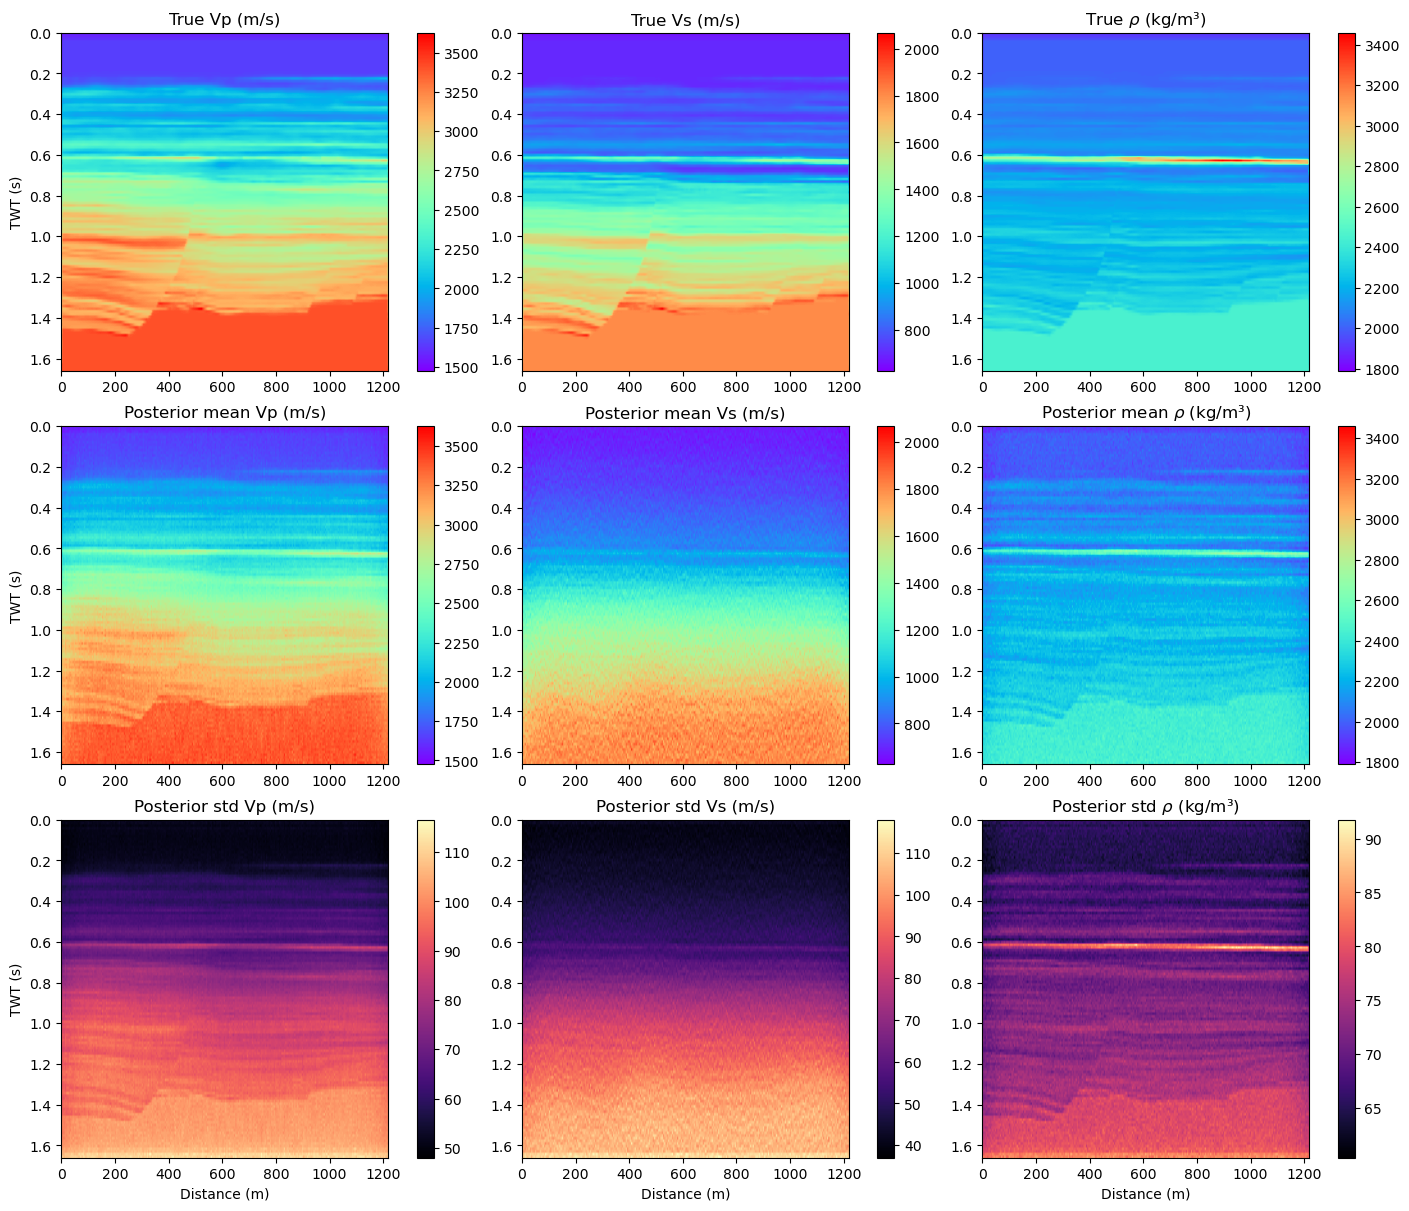

In [15]:
# plot results

titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ (kg/m³)"]

true_models = [vp_t[:,:], vs_t[:,:], rho_t[:,:]]
mean_models = [m_post_phys[:, 0, :],m_post_phys[:, 1, :],m_post_phys[:, 2, :]]

std_models = [std_post_phys[:, 0, :],std_post_phys[:, 1, :],std_post_phys[:, 2, :]]

# normalized error: (mean - true) / std
normerr_models = [
    (mean_models[i] - true_models[i]) 
    for i in range(3)
]

fig, axs = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for i in range(3):

    vmin = true_models[i].min()
    vmax = true_models[i].max()

    # True model
    im = axs[0, i].imshow(
        true_models[i],
        aspect="auto",
        cmap="rainbow",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        extent=extent
    )
    axs[0, i].set_title(f"True {titles[i]}", )
    plt.colorbar(im, ax=axs[0, i])

    # Posterior mean
    im = axs[1, i].imshow(
        mean_models[i],
        aspect="auto",
        cmap="rainbow",
        vmin=vmin,
        vmax=vmax,
        origin="upper",
        extent=extent
    )
    axs[1, i].set_title(f"Posterior mean {titles[i]}")
    plt.colorbar(im, ax=axs[1, i])

    # Posterior std
    im = axs[2, i].imshow(
        std_models[i],
        aspect="auto",
        cmap="magma",
        origin="upper",
        extent=extent
    )
    axs[2, i].set_title(f"Posterior std {titles[i]}")

    plt.colorbar(im, ax=axs[2, i])



    axs[2,i].set_xlabel("Distance (m)")
    axs[i,0].set_ylabel("TWT (s)")

plt.show()

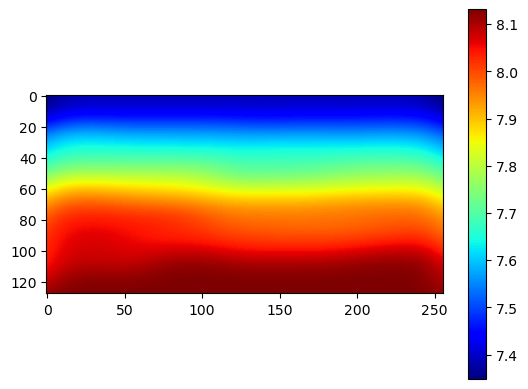

In [18]:
#inital smooth model
mback1 = mback.transpose((1,0,2))
mback1.shape

vp_back , vs_back, rho_back = mback1
vp_back.shape

plt.imshow(vp_back, cmap='jet')
plt.colorbar()

### 14. 1D trace comparison — analytical Bayesian UQ (Figure 1.11 equivalent)

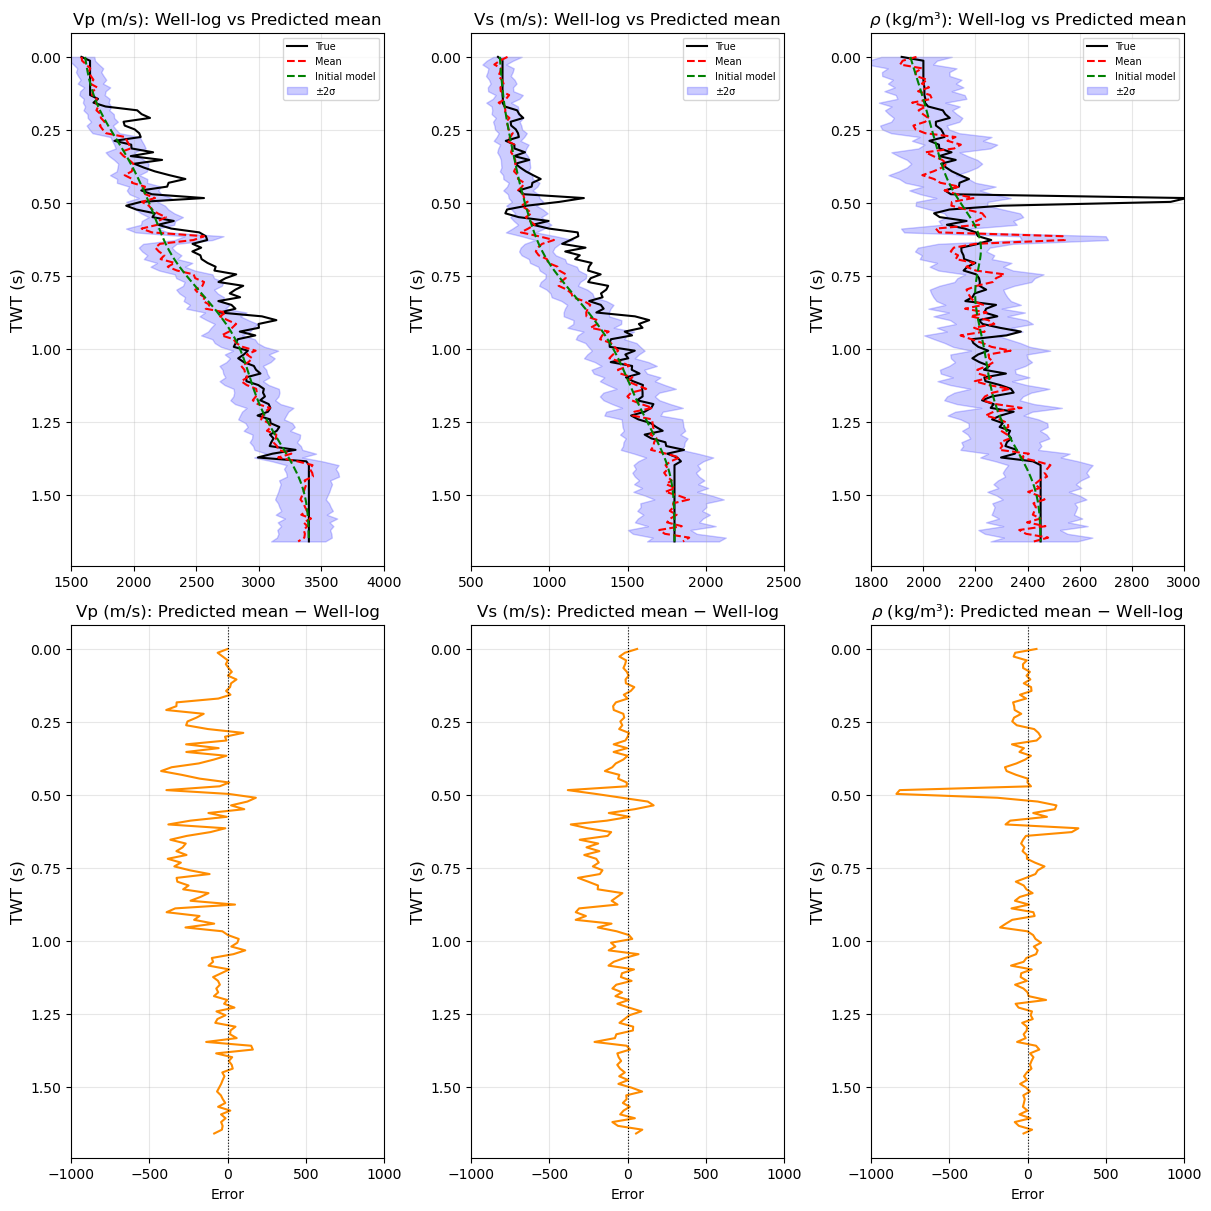

In [19]:
import matplotlib.pyplot as plt
import numpy as np

titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ (kg/m³)"]
depth = t

ix=128
true_models = [vp[:,128], vs[:,128], rho[:,128]]
mean_models = [m_post_phys[:, 0, 128],m_post_phys[:, 1, 128],m_post_phys[:, 2, 128]]

std_models = [std_post_phys[:, 0, 128],std_post_phys[:, 1, 128],std_post_phys[:, 2, 128]]

initial = [np.exp(vp_back[:,128]), np.exp(vs_back[:,128]), np.exp(rho_back[:,128])]


# normalized error: (mean - true) / std
normerr_models = [
    (mean_models[i] - true_models[i]) 
    for i in range(3)
]

# normalized error: (mean - true) / std
#normerr_models = [( mean_models[i]-true_models[i]) / (std_models[i] + 1e-5) for i in range(3)]
fig, axs = plt.subplots(2, 3, figsize=(12, 12), constrained_layout=True)

plot_min_values = [1500, 500, 1800 ]
plot_max_values = [4000, 2500, 3000 ]


for i in range(3):
    mean = mean_models[i]
    true = true_models[i]
    std  = std_models[i]
    err  = normerr_models[i]
    init = initial[i]



    # --- ±2σ shaded band ---
    ax = axs[0,i]
    ax.plot(true, depth, color="black", lw=1.5, label="True")
    ax.plot(mean, depth, color="red",   lw=1.5, linestyle="--", label="Mean")
    ax.plot(init, depth, color="green",   lw=1.5, linestyle="--", label="Initial model")
    ax.fill_betweenx(depth, mean - 2*std, mean + 2*std,
                     alpha=0.2, color="blue", label="±2σ")
    # ax.set_title(f"±2σ Band  [{coverage_2sigma:.3f}]")
    ax.set_title(f"{titles[i]}: Well-log vs Predicted mean")
    ax.set_ylabel("TWT (s)", fontsize=12)
    ax.set_xlim(plot_min_values[i], plot_max_values[i])
    ax.invert_yaxis()
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # --- Mean − True Error ---
    ax = axs[1, i]
    ax.plot(err, depth, color="darkorange", lw=1.5)
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    ax.set_title(f"{titles[i]}: Predicted mean − Well-log")
    ax.set_xlabel("Error")
    ax.set_xlim(-1000, 1000)
    ax.set_ylabel("TWT (s)", fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

#plt.suptitle("1D Posterior Analysis — Trace 242", fontsize=13, fontweight="bold")
plt.show()

---
## Part IV: Uncertainty Quantification — Diffusion Posterior Sampling (DPS)

Generates an ensemble of 100 independent posterior realizations using the guided DDPM (DPS framework, Chung et al. 2022), implementing Eqs. 1.15–1.18 of the report.

At each reverse diffusion step t, the posterior score decomposes as (Eq. 1.15):
  ∇_{m_t} log p(m_t | d) = ∇_{m_t} log p(m_t) + ∇_{m_t} log p(d | m_t)

The likelihood gradient is approximated via the Tweedie denoised estimate m̂_0 (Eq. 1.16): the data residual d − G m̂_0(m_t) is backpropagated through the denoiser to correct each reverse step toward data-consistent solutions.

Stochasticity η=1 (full DDPM ancestral sampling) is used to maximize ensemble spread for UQ — as described in Sec. 1.3.6.

### 15. Load global normalization statistics from training data

In [22]:
# for global norm using the vmin and vmax of train data per channel
import h5py

with h5py.File('../data/datah5/train_den_ddpm_3ch_global.h5', 'r') as f:
    print(list(f.keys()))          # see top-level groups/datasets
    data = f['train'][:]    # load a dataset as numpy array
    train_max = f['global_max'][:]
    #train_max = f['global_max'][:]
    train_min = f['global_min'][:]

['global_max', 'global_min', 'train']


### 16. Normalize background model to [−1, 1] (training scale) for DPS warm-start

In [23]:
train_max
train_min

# Normalize background model to [-1,1] using global channel stats
mback_normg = normalize_m11_logmodel(mback, train_min, train_max).astype(np.float32)
# PyTorch wants (B, C, H, W)
m0_normg = torch.from_numpy(mback_normg).permute(1, 0, 2).unsqueeze(0)
# shape: (1, 3, nz, nx)
mback_normg.shape

(128, 3, 256)

### 17. Sanity check: training vs Otway normalization ranges

In [24]:
print('vmin_train:', train_min)
print('vmax_train:', train_max)
print('vmin_test:', vmin)
print('vmax_test:', vmax)

vmin_train: [6.9353704 5.966704  7.331383 ]
vmax_train: [8.744048  8.437151  7.9648857]
vmin_test: 1788.8889
vmax_test: 3460.2092


### 18. Generate DPS posterior ensemble — 100 independent realizations

Core DPS inference loop: each of the 100 realizations runs a full guided reverse diffusion from a distinct random seed (Eq. 1.18, Sec. 1.3.4–1.3.6 of the report).

Key `dps_ddim_avo` parameters and their correspondence to the report:
- `num_inference_steps=800`: reverse diffusion steps T→0; 800 steps gives higher-fidelity samples than the 100-step unconditional check above
- `eta=1`: full DDPM stochastic sampling (η=1 in Eq. 1.14), maximizing posterior exploration across realizations; η=0 would collapse to a single deterministic trajectory
- `alpha_guidance=1`: guidance step size μ in Eq. 1.18, weighting the data-consistency correction G^H(d − G m̂_0) relative to the prior score at each reverse step
- `warm_start_bg=m0_normg`: initializes near the smooth background rather than pure Gaussian noise, anchoring the inversion to the low-frequency geological model
- `t_start_frac=0.1`: starts the reverse chain at 10% of T (i.e., t=100 in T=1000 steps), limiting DPS to the fine-scale refinement regime and avoiding long-range structural hallucination from pure noise
- `jacobian_mode="full"`: uses the exact Jacobian ∇_{m_t} m̂_0(m_t) in Eq. 1.16 via autograd backpropagation, rather than the identity approximation; this is the standard DPS gradient formulation of Chung et al. (2022)
- `rms_clip=0.25`: clips the guidance gradient by RMS to prevent exploding corrections that destabilize the reverse diffusion trajectory

Each realization uses a unique `generator.manual_seed(i)` to ensure statistical independence of the 100 posterior samples (Eq. 1.19–1.20).

In [25]:
n_samples = 100

samples = []

for i in range(n_samples):

    print(f"DPS sample {i+1}/{n_samples}")

    generator = torch.Generator(device=device)
    generator.manual_seed(i)

    x_final_norm = dps_ddim_avo(
        unet=model,
        scheduler=scheduler,
        m0_norm=m0_normg.to(device),
        G=G,
        d_angle_gathers=dPPn_stacks,
        vmin=train_min,#vmin,
        vmax= train_max,  #vmax,
        num_inference_steps=800,
        eta=1,#0.2,                   # stochastic DDIM
        alpha_guidance=1,
        last_frac=1,
        rms_clip=0.25,
        warm_start_bg=m0_normg.to(device),
        t_start_frac=0.1,
        jacobian_mode="full",
        device=device,
        generator=generator
    )

    samples.append(x_final_norm.detach().cpu())

DPS sample 1/100


DPS-DDIM AVO: 100%|██████████| 79/79 [00:12<00:00,  6.21it/s]


DPS sample 2/100


DPS-DDIM AVO: 100%|██████████| 79/79 [00:12<00:00,  6.33it/s]


DPS sample 3/100


...

DPS-DDIM AVO: 100%|██████████| 79/79 [00:13<00:00,  5.98it/s]


DPS sample 99/100


DPS-DDIM AVO: 100%|██████████| 79/79 [00:13<00:00,  5.97it/s]


DPS sample 100/100


DPS-DDIM AVO: 100%|██████████| 79/79 [00:13<00:00,  6.02it/s]


### 19. Denormalize DPS samples and compute posterior statistics

Converts the 100 DPS samples from normalized [−1, 1] space to physical units


Posterior statistics are computed across the 100-sample ensemble (Eqs. 1.19–1.20 of the report):
  m̄ = (1/Ns) · Σ_k m^(k)        [posterior mean]
  σ_DPS = sqrt(1/(Ns−1) · Σ_k (m^(k) − m̄)²)   [posterior std]

In [26]:
#stack list of tensors -> tensor
samples1 = torch.stack(samples)[:, 0]   # (Nsamples, 3, nz, nx)

samples_np = samples1.numpy()

samples_phys = []

vmin = train_min#np.array([logvp_min, logvs_min, logrho_min], dtype=np.float32)
vmax = train_max #np.array([logvp_max, logvs_max, logrho_max], dtype=np.float32)
for i in range(n_samples):
    m_log_i = denormalize_m11_logmodel(
        samples_np[i].transpose(1, 0, 2),   # (nz,3,nx)
        vmin,
        vmax
    ).transpose(1, 0, 2)                    # (3,nz,nx)

    m_phys_i = np.exp(m_log_i)
    samples_phys.append(m_phys_i)

samples_phys = np.stack(samples_phys, axis=0)   # (Nsamples, 3, nz, nx)

mean_phys = samples_phys.mean(axis=0)
std_phys  = samples_phys.std(axis=0)

vp_mean, vs_mean, rho_mean = mean_phys
vp_std,  vs_std,  rho_std  = std_phys

### 20. Visualize DPS posterior UQ — 2D sections (Figure 1.8)

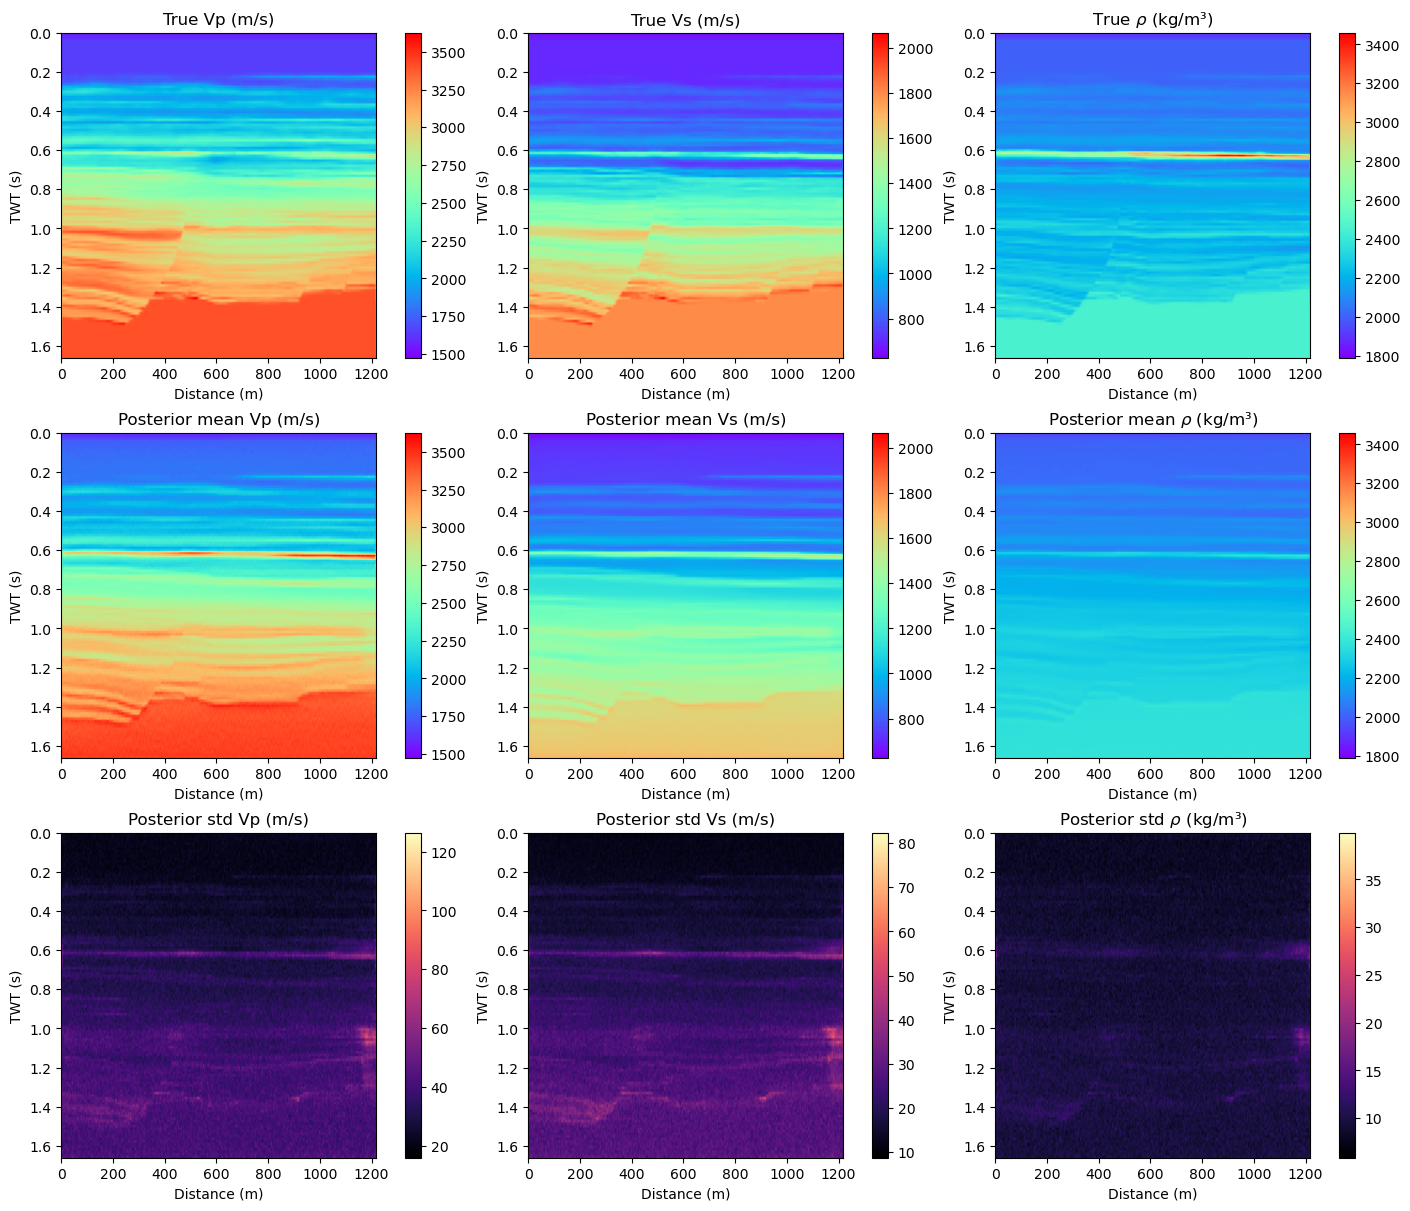

In [27]:
# Plot results
titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ (kg/m³)"]
ix=128
true_models = [vp_t, vs_t, rho_t]
mean_models = [vp_mean,vs_mean,rho_mean]

std_models = [vp_std,vs_std,rho_std]

# normalized error: (mean - true) / std
normerr_models = [( mean_models[i]-true_models[i]) / (std_models[i] + 1e-5) for i in range(3)]

fig, axs = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)

for i in range(3):

    vmin = true_models[i].min()
    vmax = true_models[i].max()

    # True model
    im = axs[0, i].imshow(true_models[i],aspect="auto", cmap="rainbow",vmin=vmin,vmax=vmax,origin="upper", extent=extent)
    axs[0, i].set_title(f"True {titles[i]}")
    plt.colorbar(im, ax=axs[0, i])

    # Posterior mean
    im = axs[1, i].imshow(mean_models[i],aspect="auto",cmap="rainbow",vmin=vmin,vmax=vmax,origin="upper", extent=extent)
    axs[1, i].set_title(f"Posterior mean {titles[i]}")
    plt.colorbar(im, ax=axs[1, i])

    # Posterior std
    im = axs[2, i].imshow(std_models[i],aspect="auto",cmap="magma",origin="upper", extent=extent)
    axs[2, i].set_title(f"Posterior std {titles[i]}")
    plt.colorbar(im, ax=axs[2, i])

    # Normalized error
    #im = axs[3, i].imshow(normerr_models[i],aspect="auto",cmap="rainbow",vmin=-10,vmax=10,origin="upper")
    #axs[3, i].set_title(f"(Mean − True) / Std ")
    #plt.colorbar(im, ax=axs[3, i])

for ax in axs.flat:
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("TWT (s)")

plt.show()

### 21. 1D trace comparison — DPS posterior UQ (Figure 1.10 equivalent)

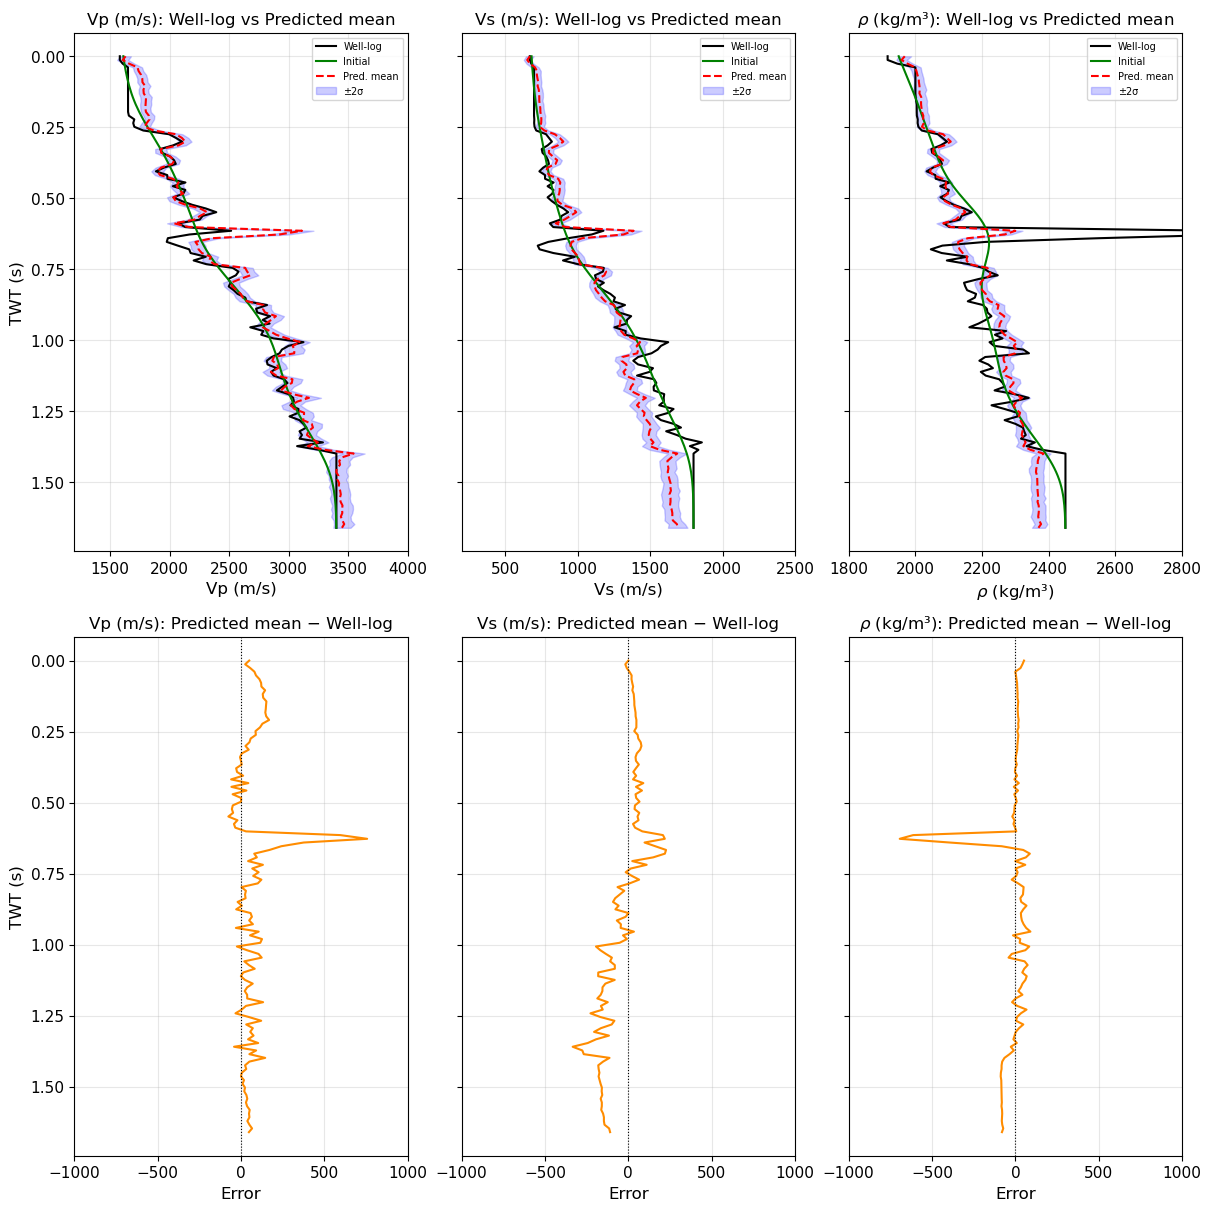

In [29]:
import matplotlib.pyplot as plt
import numpy as np

titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ (kg/m³)"]
depth = t

ix=128
true_models = [vp_t[:,128], vs_t[:,128], rho_t[:,128]]
mean_models = [vp_mean[:,128],vs_mean[:,128],rho_mean[:,128]]

std_models = [vp_std[:,128],vs_std[:,128],rho_std[:,128]]


initial = [np.exp(vp_back[:,128]), np.exp(vs_back[:,128]), np.exp(rho_back[:,128])]



# normalized error: (mean - true) / std
normerr_models = [( mean_models[i]-true_models[i]) for i in range(3)]
#fig, axs = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

plot_min_values = [1200, 200, 1800 ]
plot_max_values = [4000, 2500, 2800 ]

#plot_min_values = [-1, -1, -1 ]
#plot_max_values = [1, 1, 1 ]

fig, axs = plt.subplots(2, 3, figsize=(12, 12), constrained_layout=True, sharey=True)

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=11)

for i in range(3):
    mean = mean_models[i]
    true = true_models[i]
    std  = std_models[i]
    err  = normerr_models[i]
    init = initial[i]


    # --- ±2σ shaded band ---
    ax = axs[0, i]
    ax.plot(true, depth, color="black", lw=1.5, label="Well-log")
    ax.plot(init, depth, color="green", lw=1.5, label="Initial")
    ax.plot(mean, depth, color="red",   lw=1.5, linestyle="--", label="Pred. mean")
    #ax.plot(p_mean, depth, color="magenta",   lw=1.5, linestyle="--", label="Prior mean")

    ax.fill_betweenx(depth, mean - 2*std, mean + 2*std,
                     alpha=0.2, color="blue", label="±2σ")
    
    ax.set_xlabel(titles[i], fontsize=12)
    ax.set_xlim(plot_min_values[i], plot_max_values[i])
    ax.set_title(f"{titles[i]}: Well-log vs Predicted mean")
    #ax.set_ylabel("TWT (s)", fontsize=12)
    #ax.invert_yaxis()
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # --- Mean − True Error ---
    ax = axs[1, i]
    ax.plot(err, depth, color="darkorange", lw=1.5)
    ax.axvline(0, color="black", lw=0.8, linestyle=":")
    ax.set_title(f"{titles[i]}: Predicted mean − Well-log")
    ax.set_xlabel("Error", fontsize=12)
    ax.set_xlim(-1000, 1000)
    #ax.set_ylabel("TWT (s)", fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
for row in range(2):
    axs[row,0].set_ylabel("TWT (s)", fontsize=12)
#plt.savefig('/home/dixita/dpsAVOinversion-dev/DW0127_figs/Field_well_uncertanity.png', dpi=300)
plt.show()